In [22]:
import pandas as pd
from scipy.stats import levene
import model_comparison
from model_comparison import (calc_classification_metrics, 
                              make_ci_plot_grid, 
                              make_mcs_plot_grid, 
                              make_normality_diagnostic,
                              make_boxplots_parametric, 
                              make_scatterplot,
                              rm_tukey_hsd, 
                              make_curve_plots)
import pickle

In [17]:
ad_cm60 = pd.read_csv(r'M:\ML_scripts\in-domain\CM\ad-cm60-best_trial_fold_metrics.csv').drop(columns=['Unnamed: 0'])

ad_cm60['model'] = 'ad-cm-60'
ad_cm60['cv_cycle'] = ad_cm60.index
ad_cm60['split'] = 'stratified'

ad_cm60 = ad_cm60.rename(columns={'model': 'method'})

cm60 = pd.read_csv(r'M:\ML_scripts\polaris\cm60-trials-data\best_trial_fold_metrics.csv').drop(columns=['Unnamed: 0'])
cm60['cv_cycle'] = cm60.index
cm60['split'] = 'stratified'
cm60 = cm60.rename(columns={'model': 'method'})

df_metrics = pd.concat([ad_cm60, cm60])

metric_list = list(ad_cm60.columns[1:4])

In [19]:
for metric in metric_list:
    groups = df_metrics.groupby('method')[metric].apply(list)
    stat, pvalue = levene(*groups)
    print(f'Levene test for {metric}: p-value = {pvalue}')

variances_by_model = df_metrics.groupby('method')[metric_list].var()
max_fold_diff = variances_by_model.max() / variances_by_model.min()
print('\n',max_fold_diff)

Levene test for roc_auc: p-value = 0.31899351662958303
Levene test for mcc: p-value = 0.5247393557496132
Levene test for auc_pr_cal: p-value = 0.09595098447167082

 roc_auc       2.062295
mcc           1.378486
auc_pr_cal    2.393300
dtype: float64


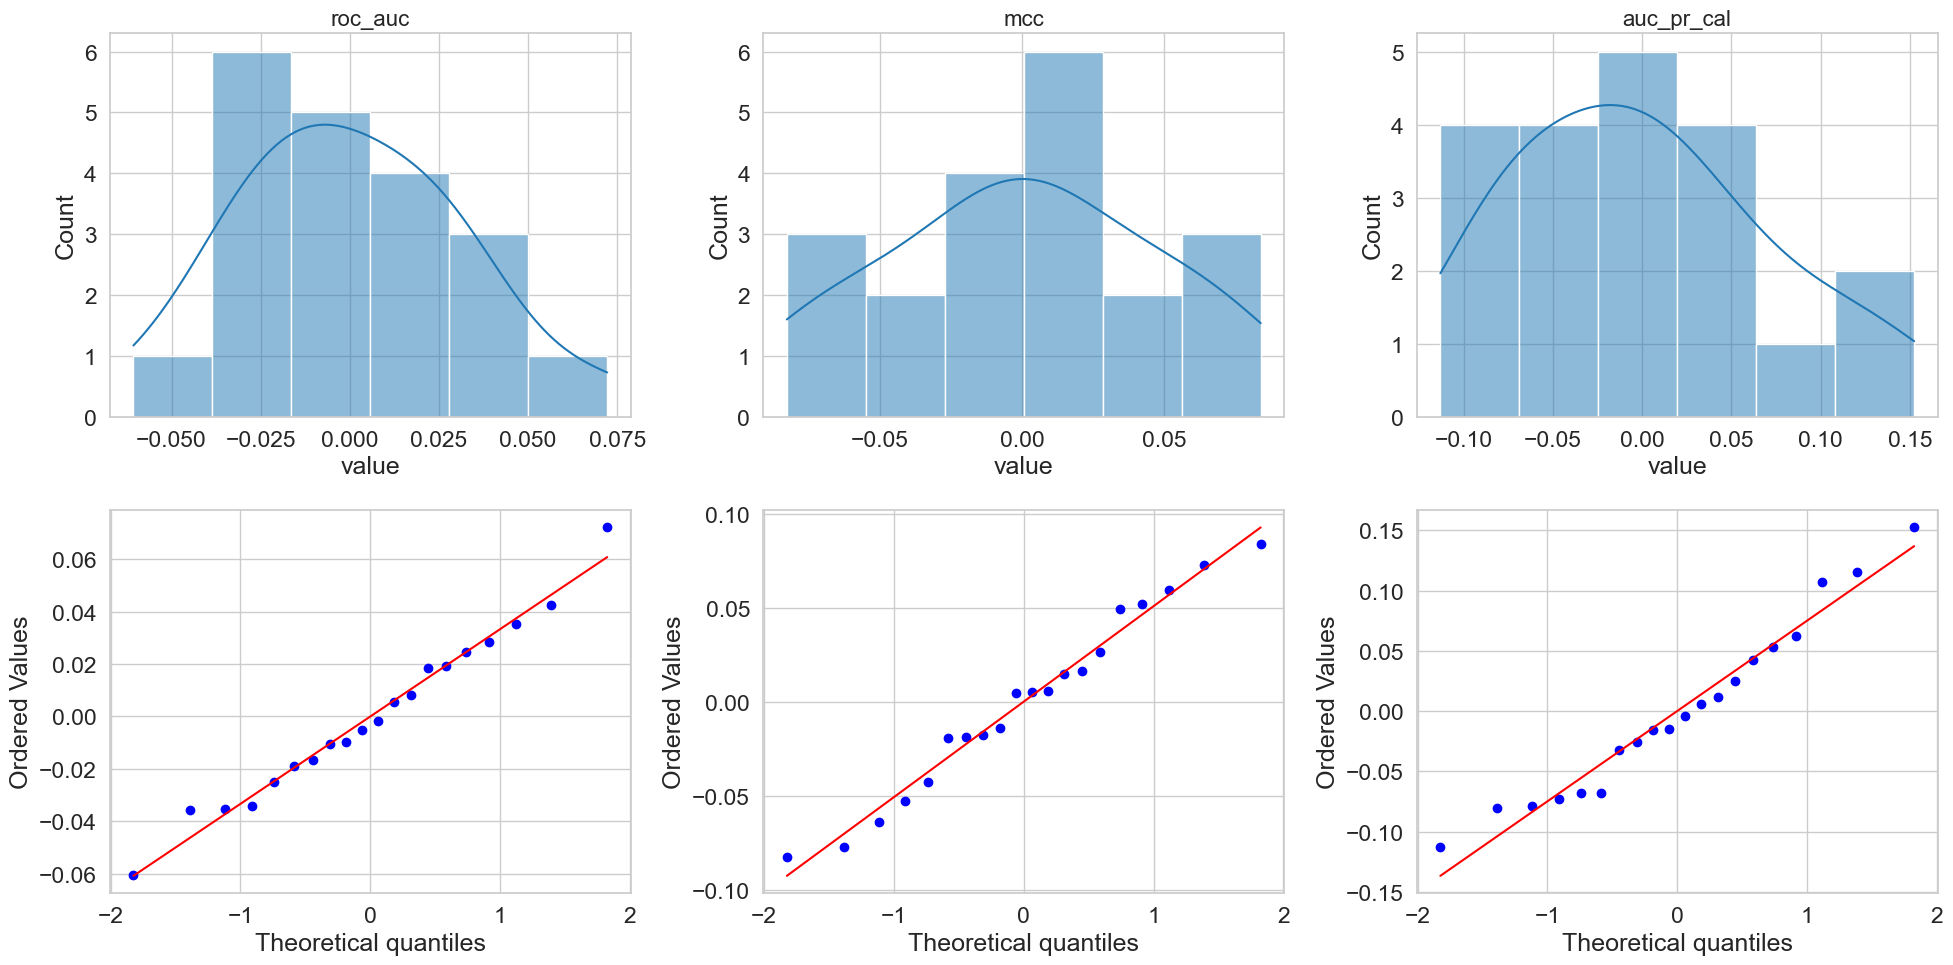

In [20]:
make_normality_diagnostic(df_metrics.copy(), metric_list)

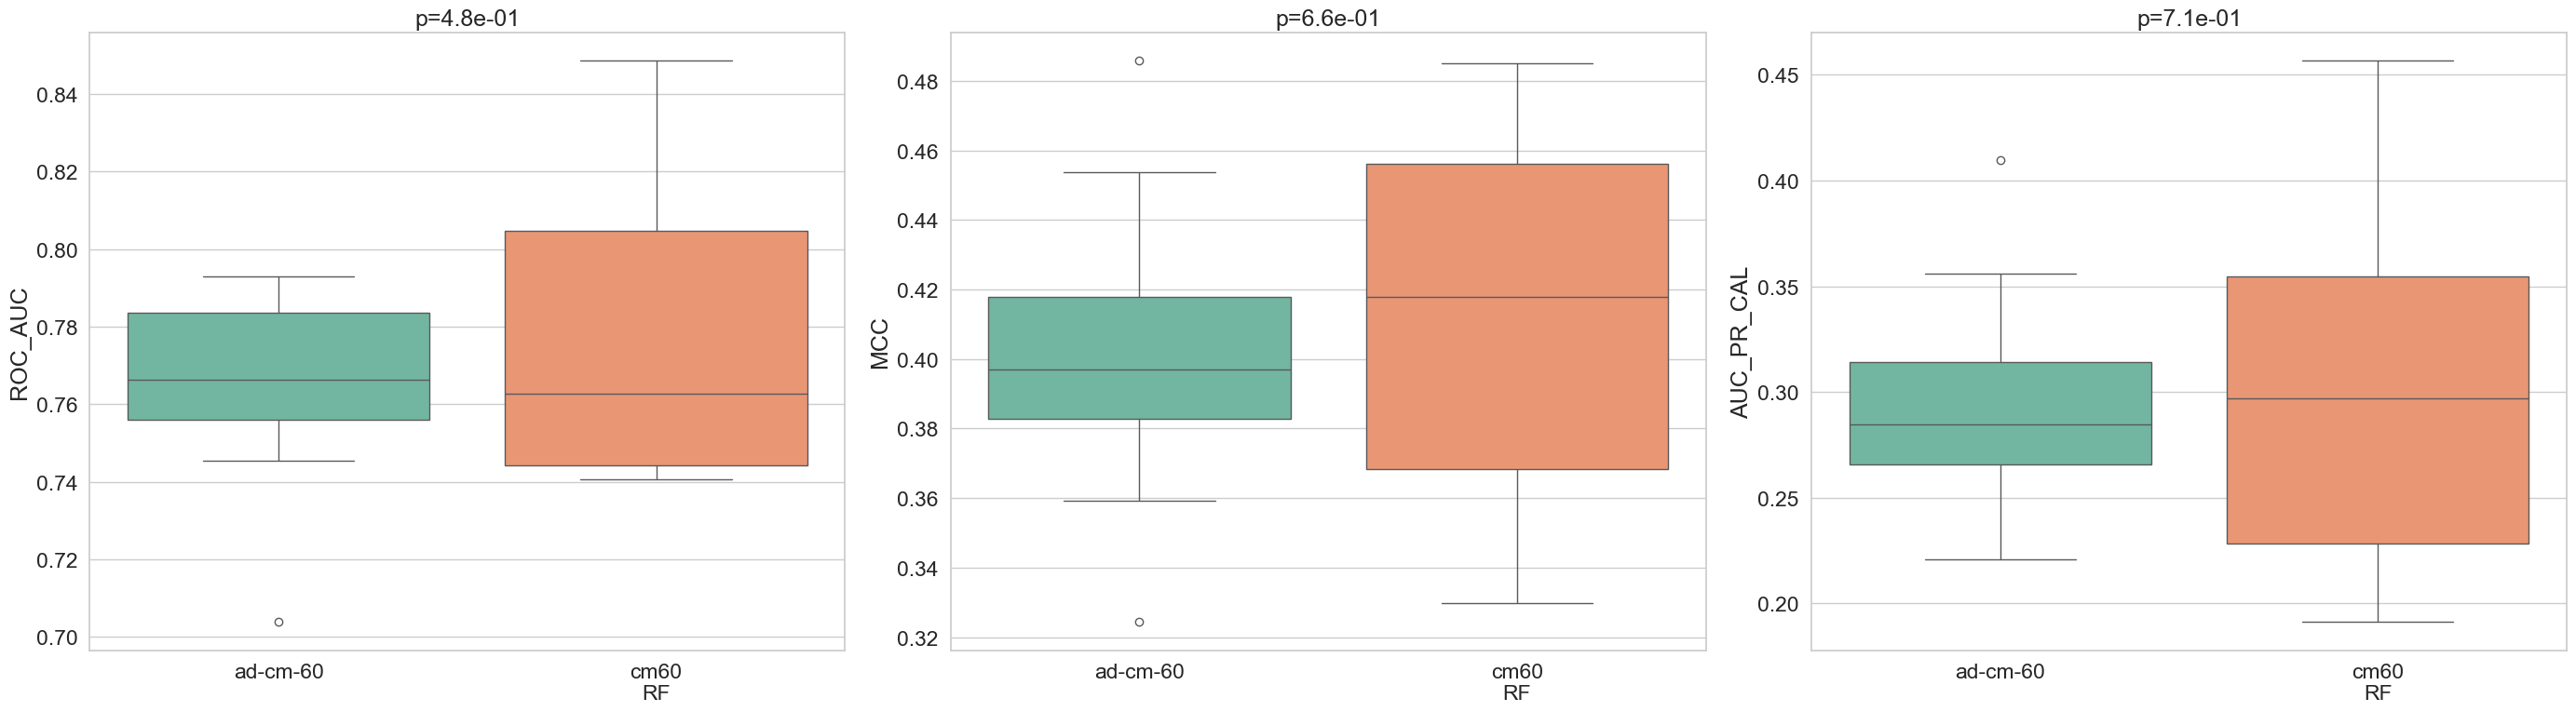

In [21]:
make_boxplots_parametric(df_metrics, metric_list)

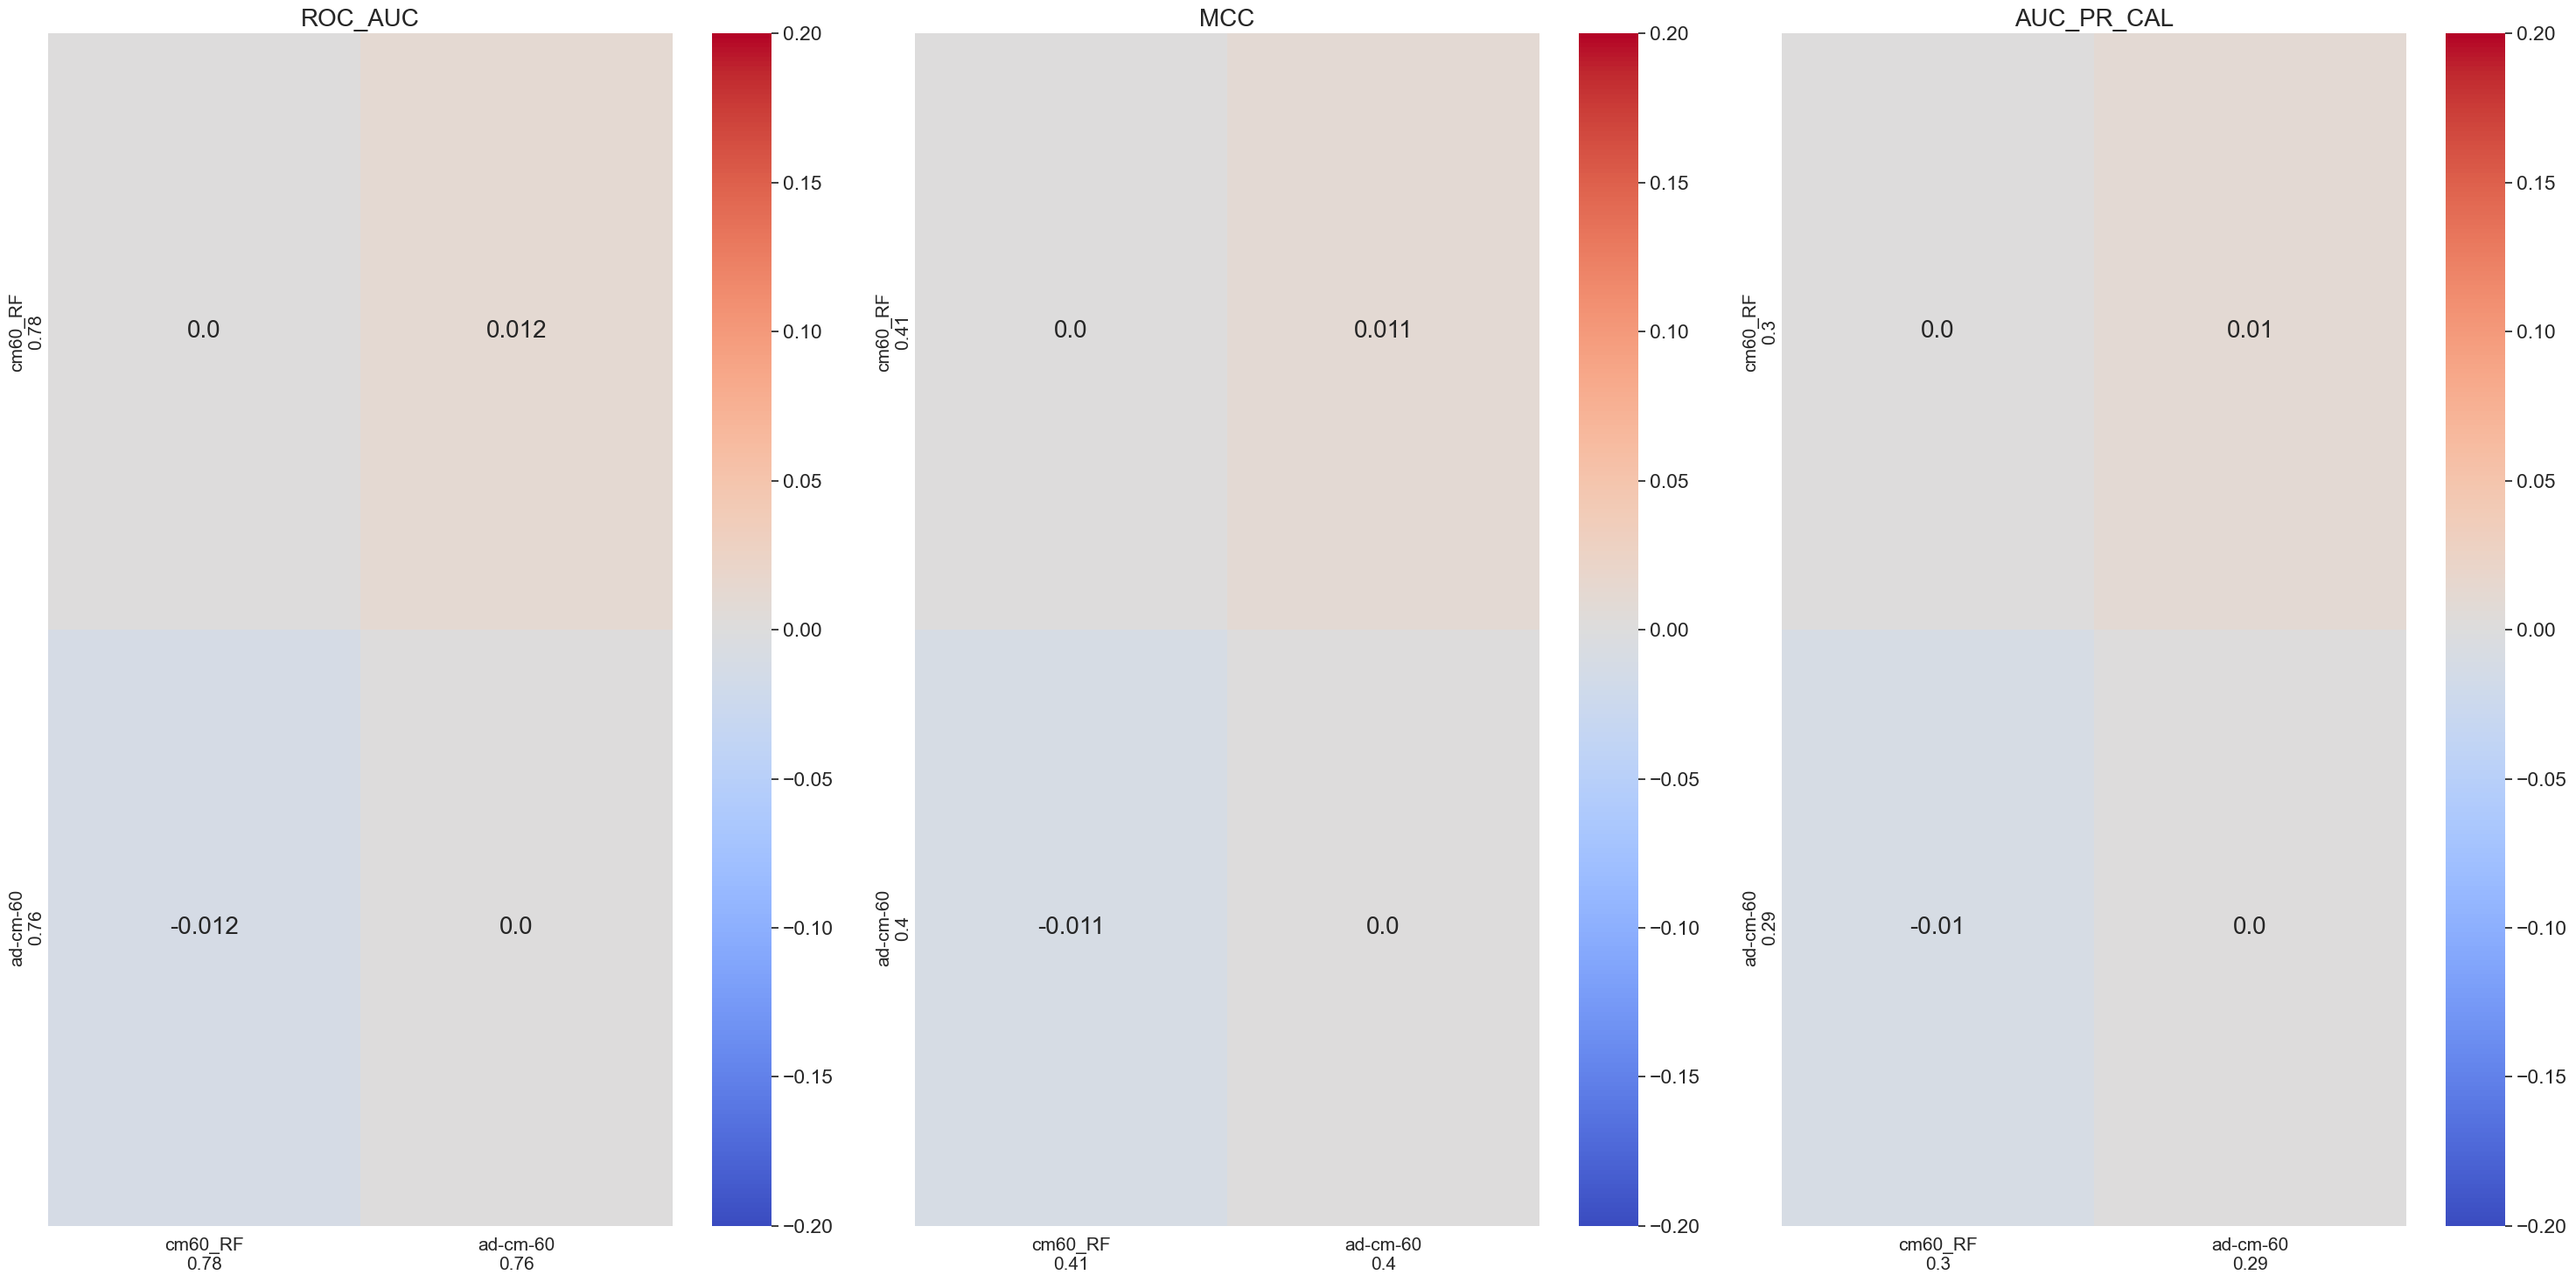

In [23]:
effect_dict = {'roc_auc':.1, 'mcc':.1, 'auc_pr_cal':.1}
direction_dict = {'roc_auc':'maximize', 'mcc':'maximize', 'auc_pr_cal':'maximize'}    

model_comparison.make_mcs_plot_grid(df_metrics, metric_list, group_col="method", effect_dict=effect_dict, direction_dict=direction_dict,
                   figsize=(30, 15), cell_text_size=20, axis_text_size=15, title_text_size=20, show_diff=True, sort_axes=True)

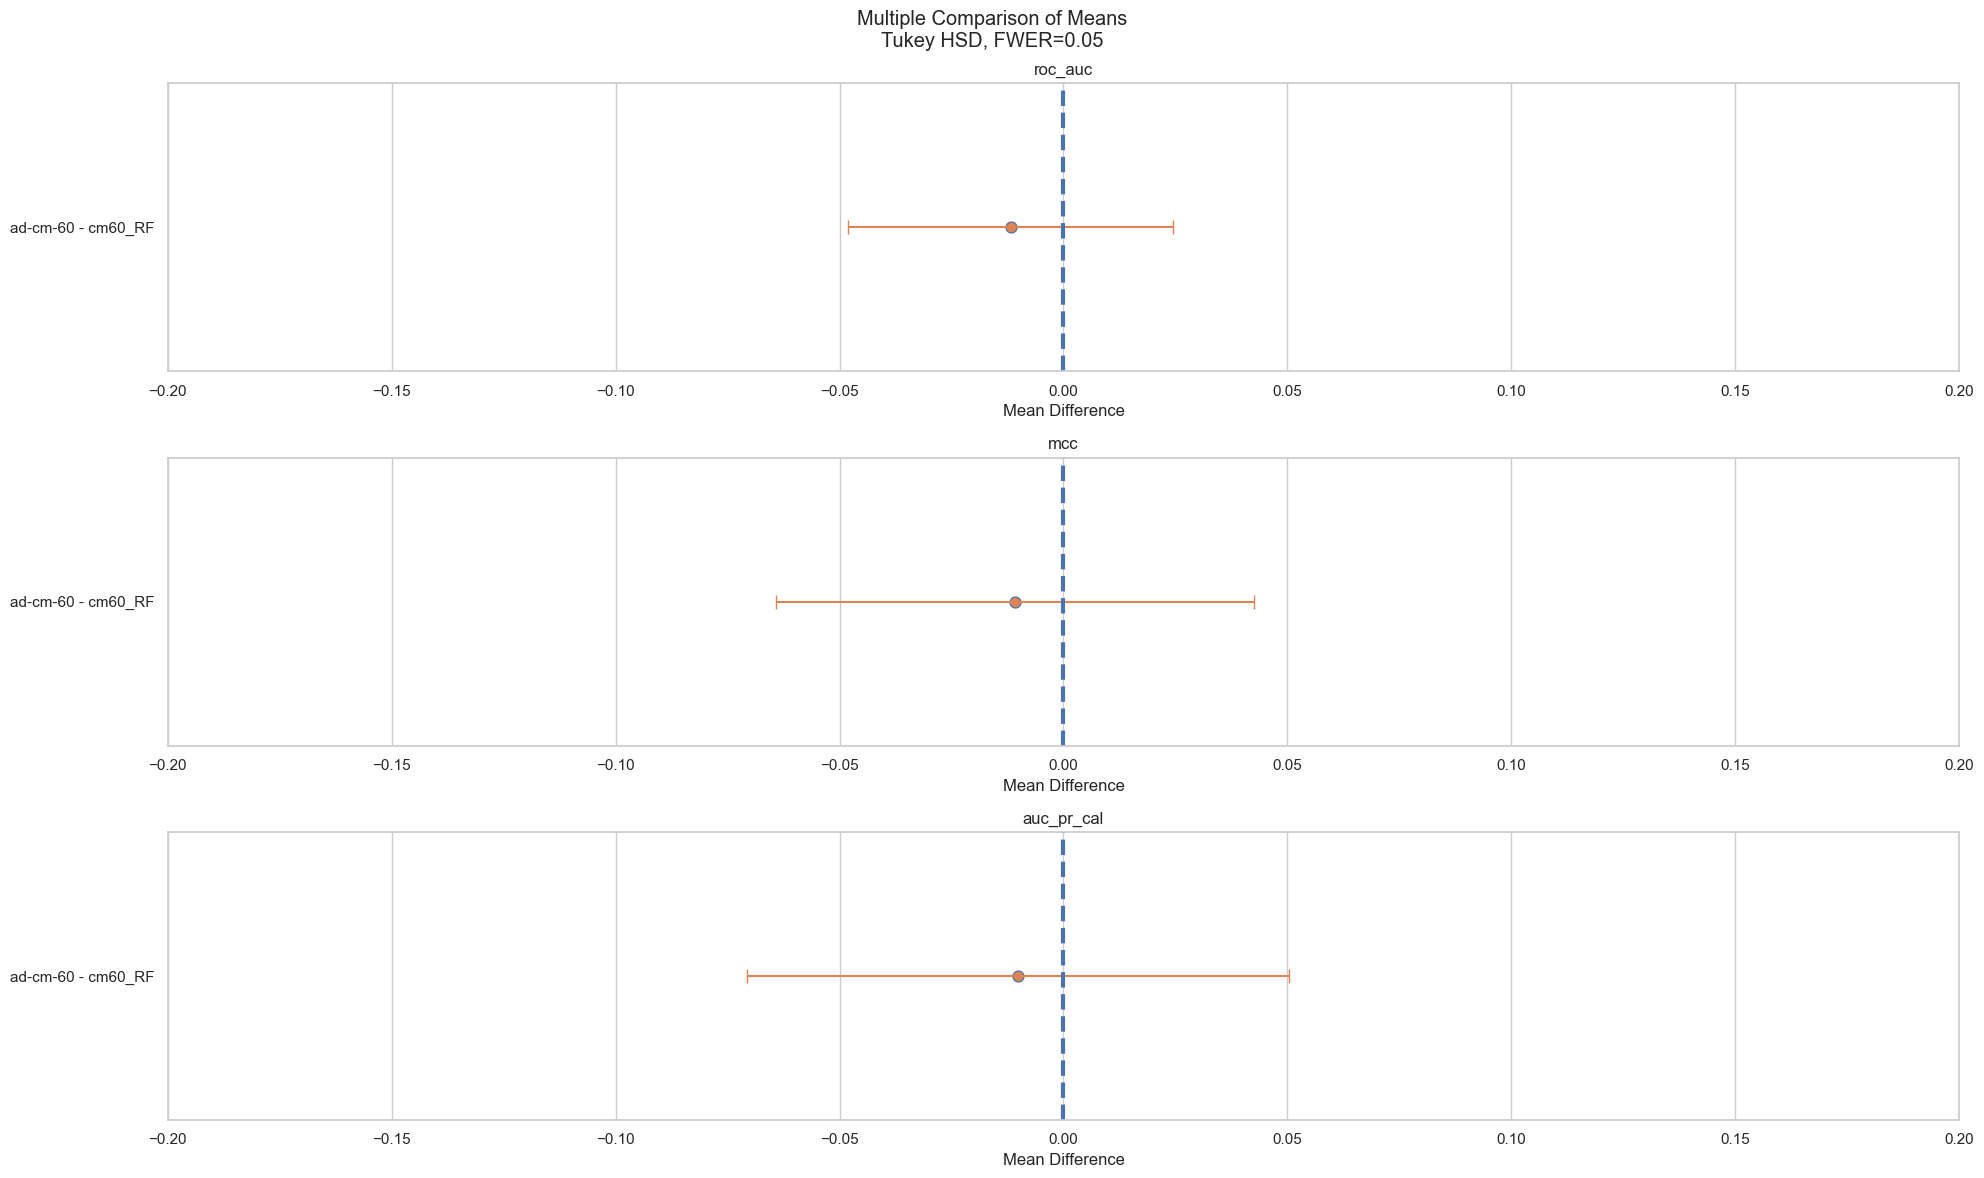

In [26]:
model_comparison.make_ci_plot_grid(df_metrics, metric_list, "method")